# Stage 2 — NLOS Signal Quality Classification (LSTM)

**Multi-Model Pipeline: Correctable vs Challenging**

Stage 2 classifies each NLOS signal as **correctable** or **challenging** for Stage 3 ranging error correction.

**Mixture labeling rule** (geometric + morphological):
- **Criterion 1 (geometric):** bounce dominance (amplitude ratio) >= 50%
- **Criterion 2 (morphological):** num_peaks <= 2
- **Correctable (0):** BOTH conditions met
- **Challenging (1):** either condition violated

**Why is this not circular?**
- Labels come from geometric ground truth (`bounce_path_idx`) + signal morphology (peak count)
- Model input is 64-dim LSTM embeddings (frozen Stage 1 encoder)
- The RF classifier never sees the labeling features directly

**Architecture:** Frozen LSTM_Classifier encoder -> 64-dim embeddings -> Random Forest Classifier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
import joblib
import os
import re

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    # ROI alignment (same as Stage 1)
    "search_start": 740,
    "search_end": 810,
    # Peak detection — morphological CIR quality
    "peak_prominence": 0.20,
    "peak_min_distance": 5,
    "dominant_path_max_peaks": 2,
    # Geometric bounce dominance (amplitude ratio)
    "bounce_search_window": 3,
    "dominance_threshold": 0.50,
    # Random Forest
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    # Split
    "test_ratio": 0.30,
    "seed": 42,
}

np.random.seed(CONFIG["seed"])
print(f"Config: {CONFIG}")
print(f"\nLabel strategy: MIXTURE (geometric + morphological)")
print(f"  Criterion 1: bounce dominance (amplitude ratio) >= {CONFIG['dominance_threshold']:.0%}")
print(f"  Criterion 2: num_peaks <= {CONFIG['dominant_path_max_peaks']}")
print(f"  Correctable (0): BOTH conditions met")
print(f"  Challenging (1): either condition violated")
print(f"  Model input:   64-dim LSTM embeddings → RF classifier")

Config: {'search_start': 740, 'search_end': 810, 'peak_prominence': 0.2, 'peak_min_distance': 5, 'dominant_path_max_peaks': 2, 'bounce_search_window': 3, 'dominance_threshold': 0.5, 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'test_ratio': 0.3, 'seed': 42}

Label strategy: MIXTURE (geometric + morphological)
  Criterion 1: bounce dominance (amplitude ratio) >= 50%
  Criterion 2: num_peaks <= 2
  Correctable (0): BOTH conditions met
  Challenging (1): either condition violated
  Model input:   64-dim LSTM embeddings → RF classifier


## 2. Data Loading & Mixture Quality Labeling

Load NLOS samples from the combined dataset and compute **mixture quality labels** using:
1. **Geometric:** bounce dominance (amplitude ratio) from floor-plan `bounce_path_idx`
2. **Morphological:** peak count in CIR ROI

In [2]:
# ==========================================
# ROI ALIGNMENT (reused from Stage 1)
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    """Find leading edge by backtracking from peak."""
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)

    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]

    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val

    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break

    return leading_edge


# ==========================================
# COUNT PEAKS IN CIR ROI
# ==========================================
def count_peaks_in_roi(sig, leading_edge, config=CONFIG):
    """Count prominent peaks in CIR ROI (120 samples from leading edge)."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0 or np.max(roi) == 0:
        return 0
    roi_norm = roi / np.max(roi)
    peaks, _ = find_peaks(
        roi_norm,
        prominence=config["peak_prominence"],
        distance=config["peak_min_distance"]
    )
    return len(peaks)


# ==========================================
# GEOMETRIC BOUNCE DOMINANCE (AMPLITUDE RATIO)
# ==========================================
def compute_bounce_dominance(sig, leading_edge, bounce_path_idx,
                              window=CONFIG["bounce_search_window"]):
    """
    Amplitude ratio: peak amplitude near bounce position / strongest peak in ROI.
    Returns 0-1. High value = bounce peak is the dominant peak.
    Not affected by ROI size or tail energy dilution.
    """
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]

    if len(roi) == 0 or np.max(roi) == 0:
        return 0.0

    # Strongest peak amplitude in entire ROI
    strongest_amp = float(np.max(roi))

    # Peak amplitude near geometric bounce position (±window samples)
    bounce_idx = int(round(bounce_path_idx))
    b_start = max(0, bounce_idx - window)
    b_end = min(len(sig), bounce_idx + window + 1)

    if b_start >= b_end:
        return 0.0

    bounce_amp = float(np.max(sig[b_start:b_end]))
    return bounce_amp / strongest_amp


# ==========================================
# STRONGEST PEAK POWER IN ROI
# ==========================================
def get_strongest_peak_power(sig, leading_edge):
    """Max CIR amplitude in ROI after RXPACC normalization."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0:
        return 0.0
    return float(np.max(roi))


# ==========================================
# LOAD NLOS DATA + MIXTURE LABELS
# ==========================================
def load_nlos_features(filepath="../dataset/channels/combined_uwb_dataset.csv"):
    """
    Load NLOS samples and compute mixture quality labels.
    Correctable: bounce dominance (amplitude ratio) >= threshold AND num_peaks <= max_peaks.
    Challenging: otherwise.
    Returns: (raw_sigs, leading_edges, nlos_df, quality_labels, num_peaks, bounce_dominance, strongest_peak_power)
    """
    print(f"Loading: {filepath}")
    df = pd.read_csv(filepath)

    # Filter NLOS only
    nlos_df = df[df["Label"] == 1].reset_index(drop=True)
    print(f"  Total samples: {len(df)}, NLOS samples: {len(nlos_df)}")

    cir_cols = sorted(
        [c for c in df.columns if c.startswith('CIR')],
        key=lambda x: int(x.replace('CIR', ''))
    )

    raw_sigs = []
    leading_edges = []
    num_peaks_list = []
    bounce_dom_list = []
    strongest_peak_power_list = []

    for idx, row in nlos_df.iterrows():
        sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values

        # RXPACC normalization
        rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
        rxpacc = float(row.get(rxpacc_col, 128.0))
        if rxpacc > 0:
            sig = sig / rxpacc

        le = get_roi_alignment(sig)
        raw_sigs.append(sig)
        leading_edges.append(le)

        # Morphological: peak count
        num_peaks_list.append(count_peaks_in_roi(sig, le))

        # Geometric: bounce dominance (amplitude ratio)
        bpi = float(row.get('bounce_path_idx', np.nan))
        if np.isnan(bpi):
            bounce_dom_list.append(0.0)
        else:
            bounce_dom_list.append(compute_bounce_dominance(sig, le, bpi))

        # Strongest peak power
        strongest_peak_power_list.append(get_strongest_peak_power(sig, le))

    num_peaks = np.array(num_peaks_list, dtype=int)
    bounce_dominance = np.array(bounce_dom_list, dtype=float)
    strongest_peak_power = np.array(strongest_peak_power_list, dtype=float)

    # ── Mixture label ──
    dom_thresh = CONFIG["dominance_threshold"]
    peak_thresh = CONFIG["dominant_path_max_peaks"]
    is_correctable = (bounce_dominance >= dom_thresh) & (num_peaks <= peak_thresh)
    quality_labels = np.where(is_correctable, 0, 1).astype(int)

    n_correctable = int(np.sum(quality_labels == 0))
    n_challenging = int(np.sum(quality_labels == 1))

    print(f"\n  Mixture labeling (amplitude ratio >= {dom_thresh:.0%} AND peaks <= {peak_thresh}):")
    print(f"    {'─' * 50}")
    print(f"    Correctable (clean bounce):     {n_correctable} ({100*n_correctable/len(quality_labels):.1f}%)")
    print(f"    Challenging (multipath/noisy):   {n_challenging} ({100*n_challenging/len(quality_labels):.1f}%)")
    print(f"    {'─' * 50}")
    print(f"    Bounce dominance stats — mean: {bounce_dominance.mean():.3f}, "
          f"median: {np.median(bounce_dominance):.3f}")
    print(f"    Peak count stats — mean: {num_peaks.mean():.2f}, "
          f"max: {num_peaks.max()}")
    print(f"    Strongest peak power stats — mean: {strongest_peak_power.mean():.4f}, "
          f"min: {strongest_peak_power.min():.4f}, max: {strongest_peak_power.max():.4f}")

    return (np.array(raw_sigs), np.array(leading_edges), nlos_df,
            quality_labels, num_peaks, bounce_dominance, strongest_peak_power)


raw_sigs, leading_edges, nlos_df, quality_labels, num_peaks, bounce_dominance, strongest_peak_power = load_nlos_features()

Loading: ../dataset/channels/combined_uwb_dataset.csv
  Total samples: 3600, NLOS samples: 1800

  Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
    ──────────────────────────────────────────────────
    Correctable (clean bounce):     506 (28.1%)
    Challenging (multipath/noisy):   1294 (71.9%)
    ──────────────────────────────────────────────────
    Bounce dominance stats — mean: 0.778, median: 0.890
    Peak count stats — mean: 4.71, max: 12
    Strongest peak power stats — mean: 35.2407, min: 5.3226, max: 65.2119


### 2b. Mixture Quality Labeling

Two independent criteria determine signal quality:

1. **Bounce dominance (amplitude ratio)** — geometric, from floor plan `bounce_path_idx`:
   - `bounce_peak_amp / strongest_peak_amp` in ±3-sample window
   - High ratio = bounce path is the dominant arrival

2. **Peak count** — morphological, from CIR signal shape:
   - Number of prominent peaks in 120-sample ROI
   - Low count = simple multipath (few reflections)

**AND rule:** Correctable only if BOTH criteria are met.

Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
  Correctable: 506 (28.1%)
  Challenging: 1294 (71.9%)


C:\Users\preca\AppData\Local\Temp\ipykernel_14512\2240448736.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=unique_groups, patch_artist=True)


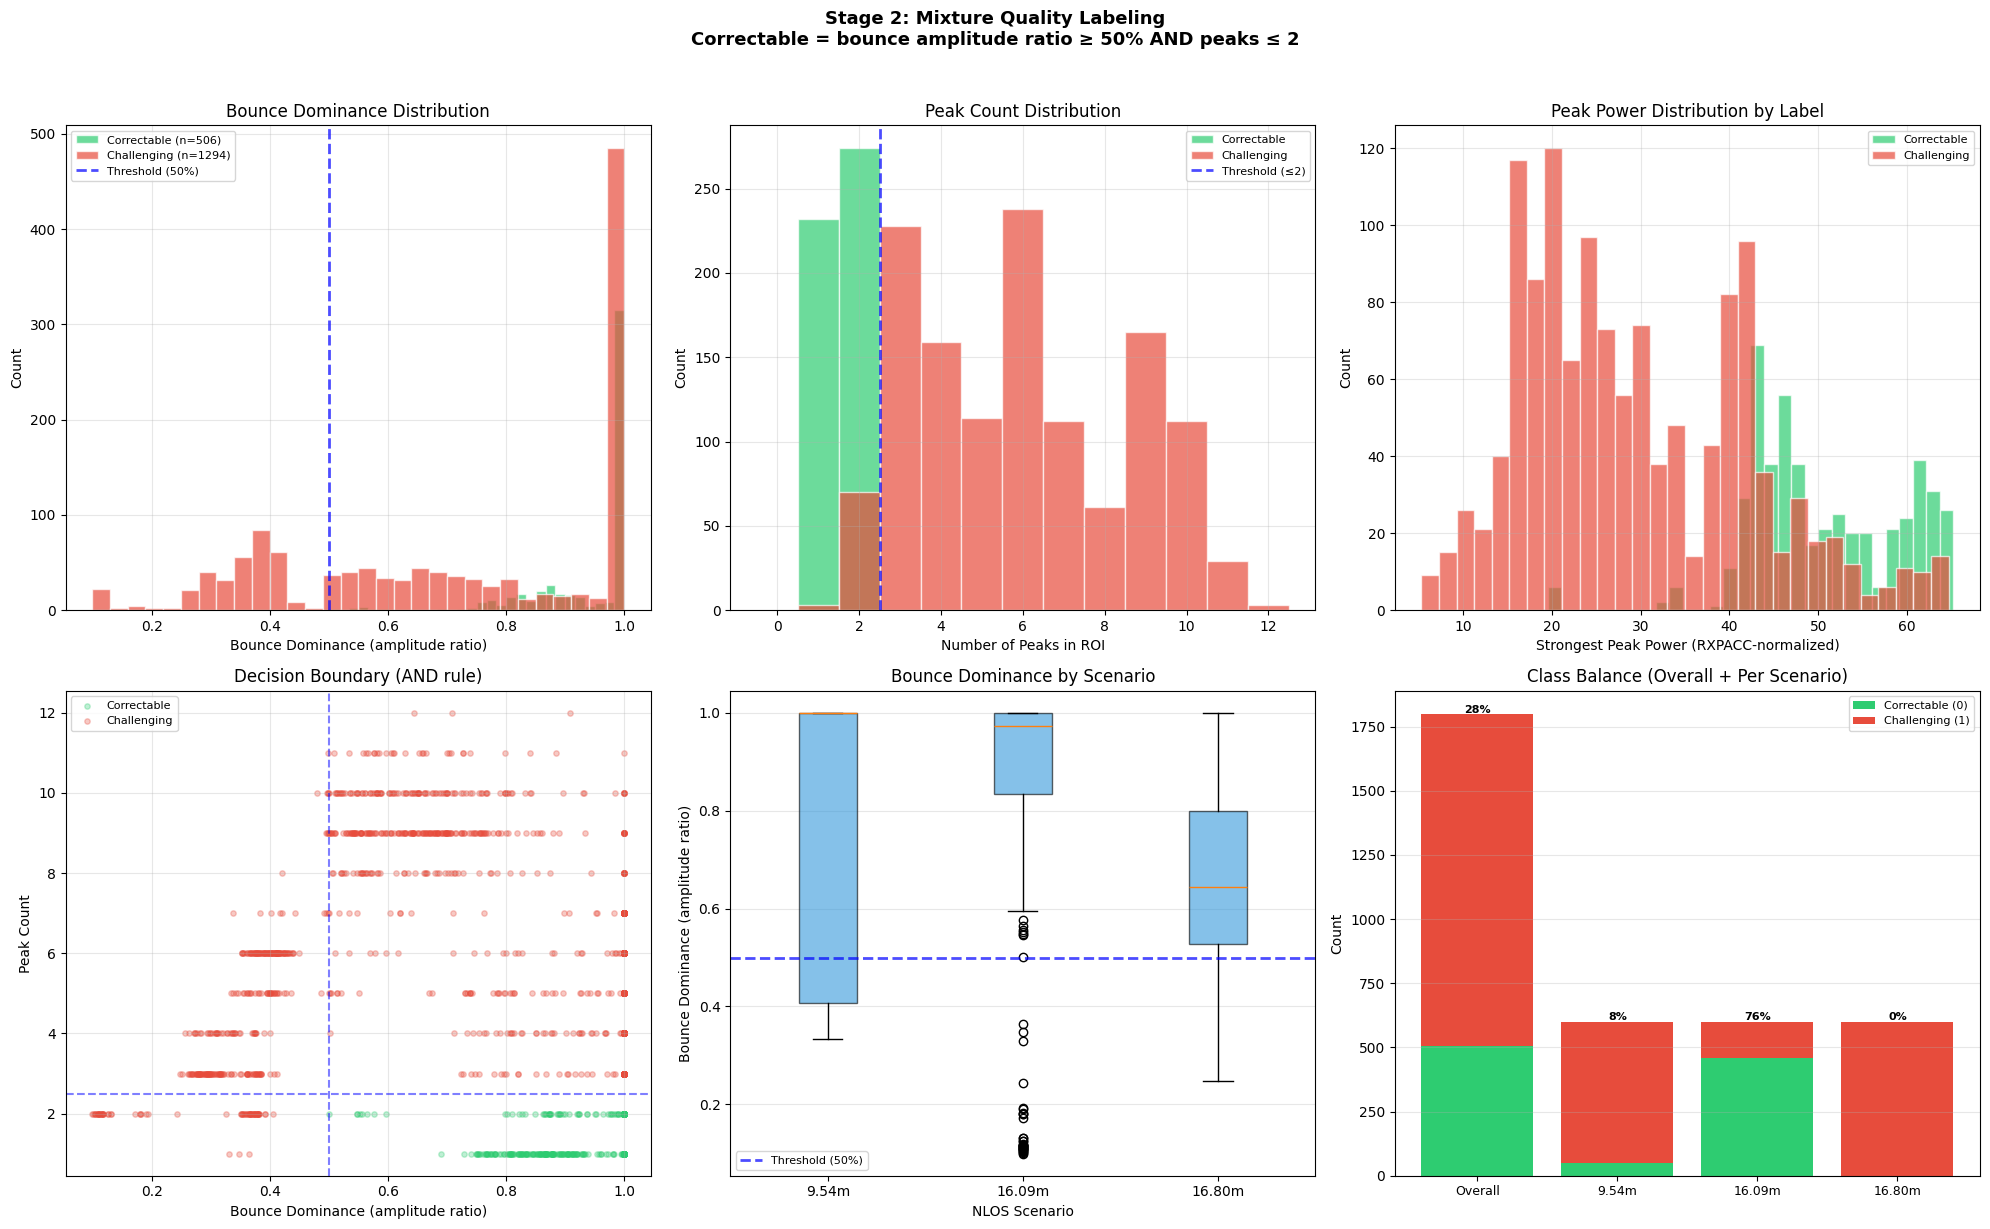

In [3]:
# ==========================================
# MIXTURE LABELING VISUALIZATION
# ==========================================
dom_thresh = CONFIG["dominance_threshold"]
peak_thresh = CONFIG["dominant_path_max_peaks"]
n_correctable = int(np.sum(quality_labels == 0))
n_challenging = int(np.sum(quality_labels == 1))

print(f"Mixture labeling (amplitude ratio >= {dom_thresh:.0%} AND peaks <= {peak_thresh}):")
print(f"  Correctable: {n_correctable} ({100*n_correctable/len(quality_labels):.1f}%)")
print(f"  Challenging: {n_challenging} ({100*n_challenging/len(quality_labels):.1f}%)")

fig, axs = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

correctable_mask = quality_labels == 0
challenging_mask = quality_labels == 1

# ─── 1. Bounce dominance histogram ───
ax = axs[0, 0]
ax.hist(bounce_dominance[correctable_mask], bins=30, color='#2ecc71', alpha=0.7,
        label=f'Correctable (n={n_correctable})', edgecolor='white')
ax.hist(bounce_dominance[challenging_mask], bins=30, color='#e74c3c', alpha=0.7,
        label=f'Challenging (n={n_challenging})', edgecolor='white')
ax.axvline(dom_thresh, color='blue', ls='--', lw=2, alpha=0.7,
           label=f'Threshold ({dom_thresh:.0%})')
ax.set_xlabel('Bounce Dominance (amplitude ratio)')
ax.set_ylabel('Count')
ax.set_title('Bounce Dominance Distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 2. Peak count histogram ───
ax = axs[0, 1]
max_peaks = int(num_peaks.max())
bins_peaks = np.arange(-0.5, max_peaks + 1.5, 1)
ax.hist(num_peaks[correctable_mask], bins=bins_peaks, color='#2ecc71', alpha=0.7,
        label='Correctable', edgecolor='white')
ax.hist(num_peaks[challenging_mask], bins=bins_peaks, color='#e74c3c', alpha=0.7,
        label='Challenging', edgecolor='white')
ax.axvline(peak_thresh + 0.5, color='blue', ls='--', lw=2, alpha=0.7,
           label=f'Threshold (≤{peak_thresh})')
ax.set_xlabel('Number of Peaks in ROI')
ax.set_ylabel('Count')
ax.set_title('Peak Count Distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 3. Strongest peak power by label ───
ax = axs[0, 2]
ax.hist(strongest_peak_power[correctable_mask], bins=30, color='#2ecc71', alpha=0.7,
        label='Correctable', edgecolor='white')
ax.hist(strongest_peak_power[challenging_mask], bins=30, color='#e74c3c', alpha=0.7,
        label='Challenging', edgecolor='white')
ax.set_xlabel('Strongest Peak Power (RXPACC-normalized)')
ax.set_ylabel('Count')
ax.set_title('Peak Power Distribution by Label')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 4. Scatter: dominance vs peak count ───
ax = axs[1, 0]
ax.scatter(bounce_dominance[correctable_mask], num_peaks[correctable_mask],
           c='#2ecc71', alpha=0.3, s=15, label='Correctable')
ax.scatter(bounce_dominance[challenging_mask], num_peaks[challenging_mask],
           c='#e74c3c', alpha=0.3, s=15, label='Challenging')
ax.axvline(dom_thresh, color='blue', ls='--', lw=1.5, alpha=0.5)
ax.axhline(peak_thresh + 0.5, color='blue', ls='--', lw=1.5, alpha=0.5)
ax.set_xlabel('Bounce Dominance (amplitude ratio)')
ax.set_ylabel('Peak Count')
ax.set_title('Decision Boundary (AND rule)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 5. Per-scenario bounce dominance boxplot ───
ax = axs[1, 1]
source_files = nlos_df['Source_File'].values
groups = []
for sf in source_files:
    match = re.search(r'([\d.]+)m_nlos', str(sf))
    groups.append(match.group(1) + 'm' if match else 'unknown')
groups = np.array(groups)
unique_groups = sorted(set(groups), key=lambda x: float(x.replace('m', '')))

box_data = [bounce_dominance[groups == g] for g in unique_groups]
bp = ax.boxplot(box_data, labels=unique_groups, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.6)
ax.axhline(dom_thresh, color='blue', ls='--', lw=2, alpha=0.7,
           label=f'Threshold ({dom_thresh:.0%})')
ax.set_xlabel('NLOS Scenario')
ax.set_ylabel('Bounce Dominance (amplitude ratio)')
ax.set_title('Bounce Dominance by Scenario')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# ─── 6. Class balance: overall + per scenario ───
ax = axs[1, 2]
x_pos = np.arange(len(unique_groups) + 1)
labels_bar = ['Overall'] + unique_groups
correctable_counts = [n_correctable]
challenging_counts = [n_challenging]
for g in unique_groups:
    mask = groups == g
    correctable_counts.append(int(np.sum(quality_labels[mask] == 0)))
    challenging_counts.append(int(np.sum(quality_labels[mask] == 1)))

ax.bar(x_pos, correctable_counts, color='#2ecc71', label='Correctable (0)')
ax.bar(x_pos, challenging_counts, bottom=correctable_counts,
       color='#e74c3c', label='Challenging (1)')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_bar, fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Class Balance (Overall + Per Scenario)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

for i in range(len(x_pos)):
    total = correctable_counts[i] + challenging_counts[i]
    pct = 100 * correctable_counts[i] / total if total > 0 else 0
    ax.text(x_pos[i], total + 5, f'{pct:.0f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle(f'Stage 2: Mixture Quality Labeling\n'
             f'Correctable = bounce amplitude ratio ≥ {dom_thresh:.0%} AND peaks ≤ {peak_thresh}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Shared LSTM Encoder — Embedding Extraction

Freeze the Stage 1 LSTM_Classifier and extract 64-dim embeddings via average pooling over the LSTM hidden states.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class LSTM_Classifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x_seq, return_dynamics=False):
        batch_size = x_seq.size(0)
        h0 = torch.zeros(1, batch_size, self.hidden_size, device=x_seq.device)
        c0 = torch.zeros(1, batch_size, self.hidden_size, device=x_seq.device)
        h_all, (h_n, c_n) = self.lstm(x_seq, (h0, c0))  # (B, 60, 64)
        h_avg = h_all.mean(dim=1)  # (B, 64)
        pred = self.classifier(h_avg)
        if return_dynamics:
            return pred, h_all
        return pred

    def embed(self, x_seq):
        """Return 64-dim embedding for Stage 2/3 compatibility."""
        batch_size = x_seq.size(0)
        h0 = torch.zeros(1, batch_size, self.hidden_size, device=x_seq.device)
        c0 = torch.zeros(1, batch_size, self.hidden_size, device=x_seq.device)
        h_all, _ = self.lstm(x_seq, (h0, c0))
        return h_all.mean(dim=1)  # (B, 64)


print(f"LSTM_Classifier defined: {sum(p.numel() for p in LSTM_Classifier().parameters()):,} params")
print(f"  Embedding dim: 64 (avg-pooled LSTM hidden states)")
print(f"  Pooling: average-over-time")

LSTM_Classifier defined: 19,265 params
  Embedding dim: 64 (avg-pooled LSTM hidden states)
  Pooling: average-over-time


In [5]:
# ==========================================
# LOAD FROZEN STAGE 1 ENCODER & EXTRACT EMBEDDINGS
# ==========================================
# Load Stage 1 config
_saved = torch.load("stage1_lstm_config.pt", map_location="cpu", weights_only=False)
STAGE1_CONFIG = _saved["config"]
print("STAGE1_CONFIG loaded from stage1_lstm_config.pt")
print(STAGE1_CONFIG)

EMBEDDING_DIM = STAGE1_CONFIG['hidden_size']  # 64
EMBEDDING_NAMES = [f'LSTM_h{i}' for i in range(EMBEDDING_DIM)]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def preprocess_cir_for_lstm(sig, leading_edge):
    """Convert a single RXPACC-normalized CIR + leading edge to 60-sample window."""
    PRE = STAGE1_CONFIG['pre_crop']
    TOTAL = STAGE1_CONFIG['total_len']
    start = max(0, leading_edge - PRE)
    end = start + TOTAL
    if end > len(sig):
        end = len(sig)
        start = max(0, end - TOTAL)
    crop = sig[start:end]
    if len(crop) < TOTAL:
        crop = np.pad(crop, (0, TOTAL - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(TOTAL)
    return crop


# Load frozen Stage 1 encoder (LSTM_Classifier)
lstm_encoder = LSTM_Classifier(
    input_size=STAGE1_CONFIG['input_size'],
    hidden_size=STAGE1_CONFIG['hidden_size'],
    dropout=STAGE1_CONFIG['dropout'],
).to(device)

checkpoint_path = 'stage1_lstm_best.pt'
lstm_encoder.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
lstm_encoder.eval()
for param in lstm_encoder.parameters():
    param.requires_grad = False

print(f"\nLoaded frozen Stage 1 encoder from {checkpoint_path}")
print(f"  Architecture: LSTM_Classifier (hidden={STAGE1_CONFIG['hidden_size']})")
print(f"  Device: {device}")
print(f"  Parameters: {sum(p.numel() for p in lstm_encoder.parameters()):,} (all frozen)")
print(f"  Embedding dim: {EMBEDDING_DIM} (avg-pooled LSTM hidden states)")

# Extract 64-dim LSTM embeddings for all NLOS samples
print(f"\nExtracting {EMBEDDING_DIM}-dim embeddings for {len(nlos_df)} NLOS samples...")

cir_sequences = []
for i in range(len(raw_sigs)):
    crop = preprocess_cir_for_lstm(raw_sigs[i], leading_edges[i])
    cir_sequences.append(crop)

cir_tensor = torch.tensor(
    np.array(cir_sequences).reshape(-1, STAGE1_CONFIG['total_len'], 1),
    dtype=torch.float32
).to(device)

all_embeddings = []
with torch.no_grad():
    for i in range(0, len(cir_tensor), 256):
        batch_cir = cir_tensor[i:i+256]
        emb = lstm_encoder.embed(batch_cir)  # (batch, 64)
        all_embeddings.append(emb.cpu().numpy())

embeddings = np.vstack(all_embeddings)

print(f"  Embeddings shape: {embeddings.shape}")
print(f"  Feature names: {EMBEDDING_NAMES[:3]} ... {EMBEDDING_NAMES[-1]}")
print(f"  Embedding stats — mean: {embeddings.mean():.4f}, std: {embeddings.std():.4f}")
print(f"\nReady for Random Forest training on {EMBEDDING_DIM}-dim LSTM embeddings.")

STAGE1_CONFIG loaded from stage1_lstm_config.pt
{'pre_crop': 10, 'post_crop': 50, 'total_len': 60, 'search_start': 740, 'search_end': 810, 'hidden_size': 64, 'input_size': 1, 'dropout': 0.2, 'batch_size': 64, 'max_epochs': 50, 'lr': 0.001, 'weight_decay': 0.0001, 'warmup_epochs': 3, 'patience': 10, 'grad_clip': 1.0, 'val_ratio': 0.15, 'test_ratio': 0.15, 'seed': 42}

Loaded frozen Stage 1 encoder from stage1_lstm_best.pt
  Architecture: LSTM_Classifier (hidden=64)
  Device: cuda
  Parameters: 19,265 (all frozen)
  Embedding dim: 64 (avg-pooled LSTM hidden states)

Extracting 64-dim embeddings for 1800 NLOS samples...
  Embeddings shape: (1800, 64)
  Feature names: ['LSTM_h0', 'LSTM_h1', 'LSTM_h2'] ... LSTM_h63
  Embedding stats — mean: -0.0288, std: 0.3101

Ready for Random Forest training on 64-dim LSTM embeddings.


## 4. CIR Waveform Examples

Compare **Correctable** vs **Challenging** CIR waveforms with geometric bounce position markers.

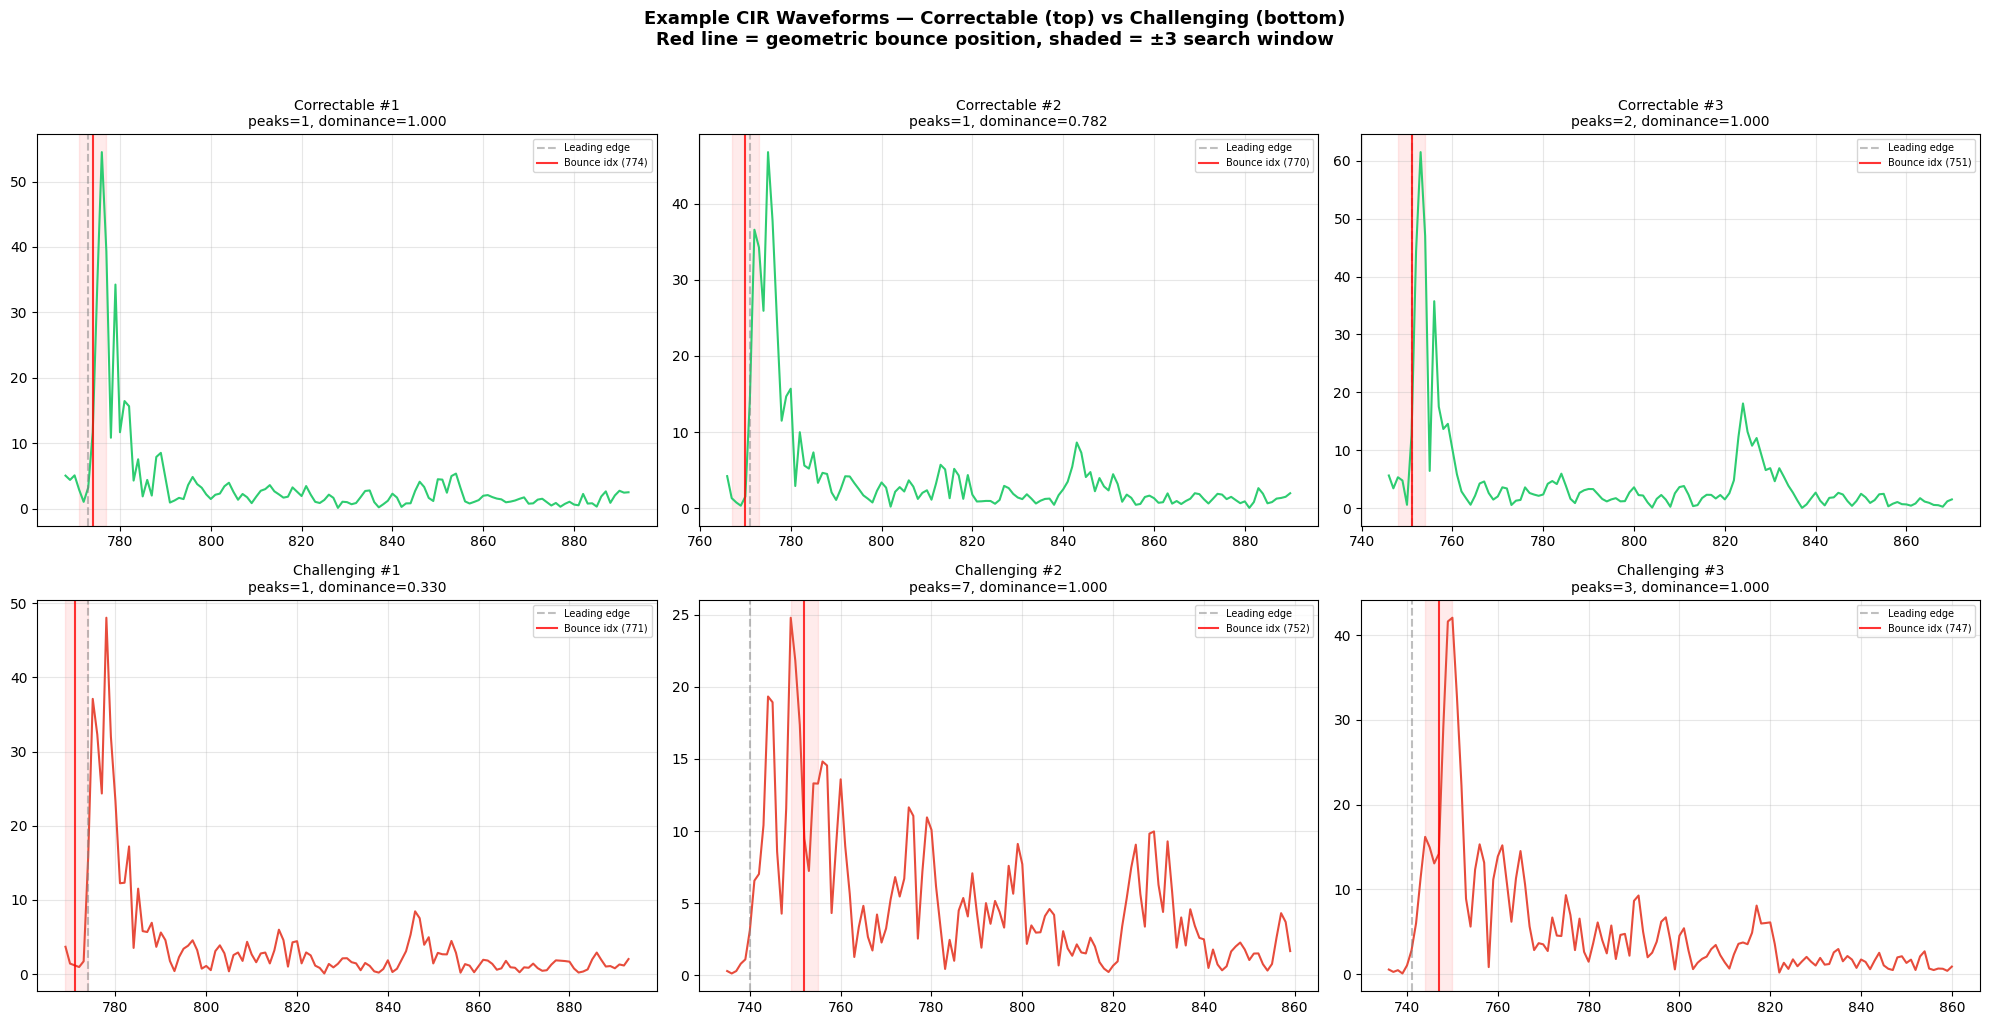

In [6]:
# ==========================================
# EXAMPLE CIR WAVEFORMS (Correctable vs Challenging)
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

W = CONFIG['bounce_search_window']
correctable_idx = np.where(quality_labels == 0)[0]
challenging_idx = np.where(quality_labels == 1)[0]

# Show 3 correctable examples (spread across dataset for diversity)
for col in range(3):
    if col >= len(correctable_idx):
        axs[0, col].axis('off')
        continue
    step = max(1, len(correctable_idx) // 3)
    idx = correctable_idx[min(col * step, len(correctable_idx) - 1)]
    sig = raw_sigs[idx]
    le = leading_edges[idx]
    bpi = float(nlos_df.iloc[idx].get('bounce_path_idx', np.nan))
    bounce_idx = int(round(bpi)) if not np.isnan(bpi) else None

    roi_start = max(0, le - 5)
    roi_end = min(len(sig), le + 120)
    x_range = np.arange(roi_start, roi_end)

    ax = axs[0, col]
    ax.plot(x_range, sig[roi_start:roi_end], color='#2ecc71', lw=1.5)
    ax.axvline(le, color='gray', ls='--', alpha=0.5, label='Leading edge')
    if bounce_idx is not None:
        ax.axvline(bounce_idx, color='red', ls='-', lw=1.5, alpha=0.8,
                   label=f'Bounce idx ({bounce_idx})')
        ax.axvspan(max(roi_start, bounce_idx - W), min(roi_end, bounce_idx + W),
                   color='red', alpha=0.08)
    ax.set_title(f"Correctable #{col+1}\n"
                 f"peaks={num_peaks[idx]}, dominance={bounce_dominance[idx]:.3f}",
                 fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Show 3 challenging examples (spread across dataset)
for col in range(3):
    if col >= len(challenging_idx):
        axs[1, col].axis('off')
        continue
    step = max(1, len(challenging_idx) // 3)
    idx = challenging_idx[min(col * step, len(challenging_idx) - 1)]
    sig = raw_sigs[idx]
    le = leading_edges[idx]
    bpi = float(nlos_df.iloc[idx].get('bounce_path_idx', np.nan))
    bounce_idx = int(round(bpi)) if not np.isnan(bpi) else None

    roi_start = max(0, le - 5)
    roi_end = min(len(sig), le + 120)
    x_range = np.arange(roi_start, roi_end)

    ax = axs[1, col]
    ax.plot(x_range, sig[roi_start:roi_end], color='#e74c3c', lw=1.5)
    ax.axvline(le, color='gray', ls='--', alpha=0.5, label='Leading edge')
    if bounce_idx is not None:
        ax.axvline(bounce_idx, color='red', ls='-', lw=1.5, alpha=0.8,
                   label=f'Bounce idx ({bounce_idx})')
        ax.axvspan(max(roi_start, bounce_idx - W), min(roi_end, bounce_idx + W),
                   color='red', alpha=0.08)
    ax.set_title(f"Challenging #{col+1}\n"
                 f"peaks={num_peaks[idx]}, dominance={bounce_dominance[idx]:.3f}",
                 fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Example CIR Waveforms — Correctable (top) vs Challenging (bottom)\n"
             f"Red line = geometric bounce position, shaded = ±{W} search window",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4b. Single-Bounce NLOS Physics

Each NLOS scenario is TX -> wall/pillar -> RX. The CIR shows:
- `los_path_idx` (blue): direct path position (blocked)
- `bounce_path_idx` (red): single-bounce reflected path
- Gap between them = NLOS ranging bias

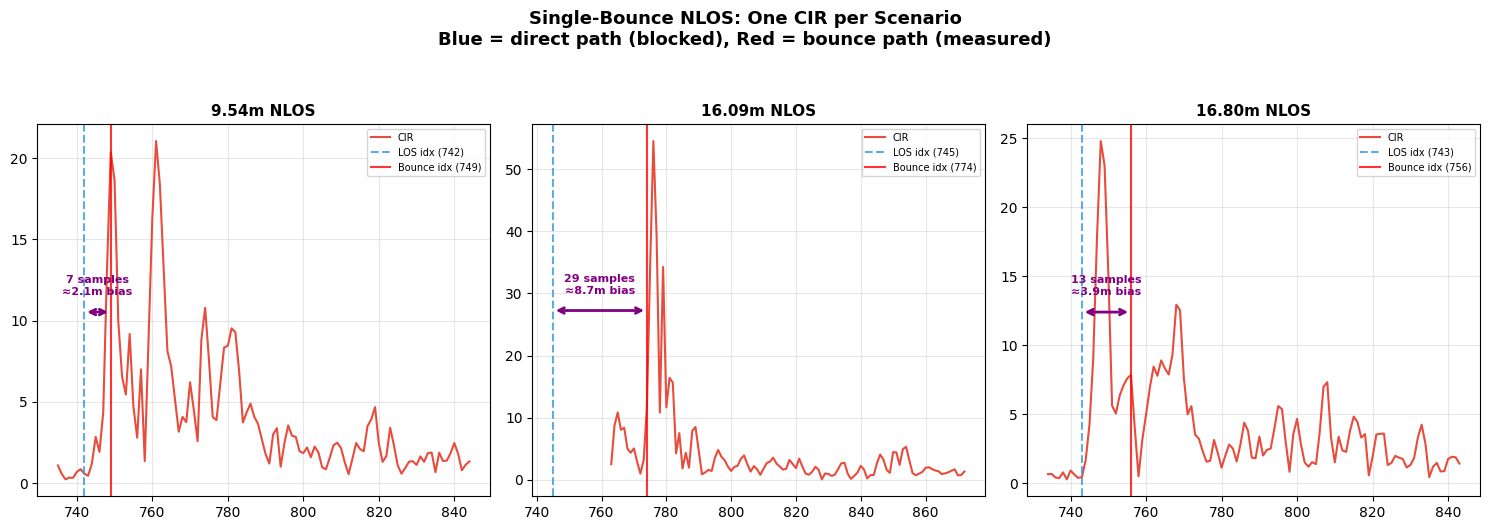


Scenario     d_direct (m)   d_bounce (m)   Bias (m)     Delay (samples) 
────────────────────────────────────────────────────────────────────
9.54m        7.668          9.540          1.872        7
16.09m       7.201          16.090         8.889        29
16.80m       13.060         16.800         3.740        13


In [7]:
# ==========================================
# SINGLE-BOUNCE NLOS PHYSICS: One CIR per Scenario
# ==========================================
source_files = nlos_df['Source_File'].values
groups = []
for sf in source_files:
    match = re.search(r'([\d.]+)m_nlos', str(sf))
    groups.append(match.group(1) + 'm' if match else 'unknown')
groups = np.array(groups)
unique_groups = sorted(set(groups), key=lambda x: float(x.replace('m', '')))

fig, axs = plt.subplots(1, len(unique_groups), figsize=(5 * len(unique_groups), 5))
if len(unique_groups) == 1:
    axs = [axs]

for i, g in enumerate(unique_groups):
    mask = groups == g
    idx = np.where(mask)[0][0]
    sig = raw_sigs[idx]
    le = leading_edges[idx]
    row = nlos_df.iloc[idx]

    bpi = float(row.get('bounce_path_idx', np.nan))
    lpi = float(row.get('los_path_idx', np.nan))

    roi_start = max(0, le - 10)
    roi_end = min(len(sig), le + 100)
    x_range = np.arange(roi_start, roi_end)

    ax = axs[i]
    ax.plot(x_range, sig[roi_start:roi_end], color='#e74c3c', lw=1.5, label='CIR')

    if not np.isnan(lpi):
        ax.axvline(int(round(lpi)), color='#3498db', ls='--', lw=1.5, alpha=0.8,
                   label=f'LOS idx ({int(round(lpi))})')
    if not np.isnan(bpi):
        ax.axvline(int(round(bpi)), color='red', ls='-', lw=1.5, alpha=0.8,
                   label=f'Bounce idx ({int(round(bpi))})')
        if not np.isnan(lpi):
            mid_y = sig[roi_start:roi_end].max() * 0.5
            ax.annotate('', xy=(int(round(bpi)), mid_y), xytext=(int(round(lpi)), mid_y),
                        arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
            delay_samples = int(round(bpi)) - int(round(lpi))
            delay_m = delay_samples * 0.3003
            ax.text((int(round(lpi)) + int(round(bpi))) / 2, mid_y * 1.1,
                    f'{delay_samples} samples\n≈{delay_m:.1f}m bias',
                    ha='center', fontsize=8, color='purple', fontweight='bold')

    ax.set_title(f'{g} NLOS', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Single-Bounce NLOS: One CIR per Scenario\n'
             'Blue = direct path (blocked), Red = bounce path (measured)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Scenario':<12} {'d_direct (m)':<14} {'d_bounce (m)':<14} {'Bias (m)':<12} {'Delay (samples)':<16}")
print('─' * 68)
for g in unique_groups:
    mask = groups == g
    idx = np.where(mask)[0][0]
    row = nlos_df.iloc[idx]
    d_direct = float(row.get('d_direct', np.nan))
    d_bounce = float(row.get('d_bounce', np.nan))
    bpi = float(row.get('bounce_path_idx', np.nan))
    lpi = float(row.get('los_path_idx', np.nan))
    bias = d_bounce - d_direct if not (np.isnan(d_bounce) or np.isnan(d_direct)) else np.nan
    delay = int(round(bpi)) - int(round(lpi)) if not (np.isnan(bpi) or np.isnan(lpi)) else np.nan
    print(f"{g:<12} {d_direct:<14.3f} {d_bounce:<14.3f} {bias:<12.3f} {delay}")

## 5. Random Forest on LSTM Embeddings + Strongest Peak Power

Ablation study:
- **Version A:** LSTM-only (64-dim embeddings)
- **Version B:** LSTM + strongest_peak_power (65-dim)

Architecture: Frozen LSTM_Classifier -> 64-dim embeddings -> Random Forest

ABLATION: LSTM-only (64-dim) vs LSTM + strongest_peak_power (65-dim)
Dataset: combined_uwb_dataset.csv (1800 NLOS, 70/30 stratified split)
  Train: 1260, Test: 540

Metric                    LSTM-only (64d)  LSTM+SPP (65d)          Δ
──────────────────────────────────────────────────────────────────────
Overall Accuracy                   93.33%          93.89%     +0.56%
ROC AUC                            0.9772          0.9790    +0.0019

Correctable precision               0.863           0.879     +0.016
Correctable recall                  0.908           0.908     +0.000
Correctable f1-score                0.885           0.893     +0.009

Challenging precision               0.963           0.963     +0.000
Challenging recall                  0.943           0.951     +0.008
Challenging f1-score                0.953           0.957     +0.004



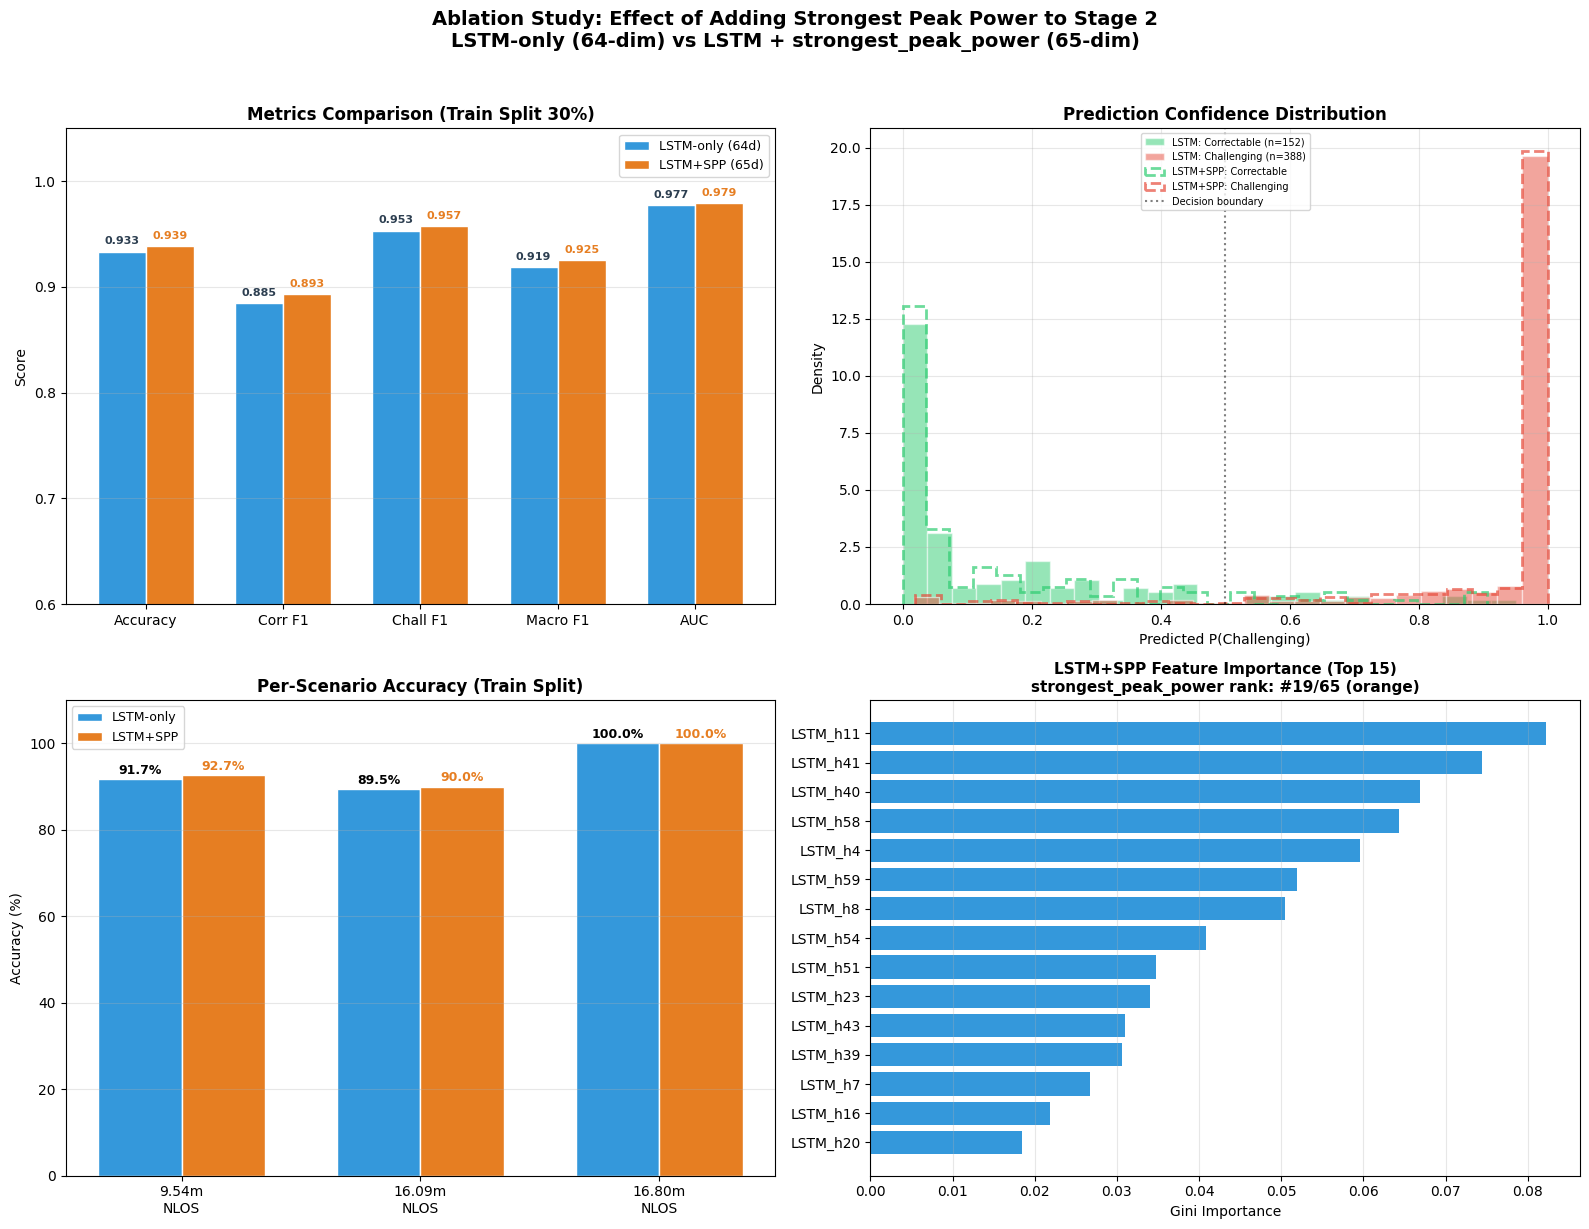


→ LSTM-only (64-dim) selected: Acc=93.33%, AUC=0.9772


In [8]:
# ==========================================
# ABLATION: LSTM-only (64-dim) vs LSTM + strongest_peak_power (65-dim)
# ==========================================

# ── Version A: LSTM embeddings only (64-dim) ──
X_lstm_only = embeddings  # (1800, 64)
y_all = quality_labels

X_train_a, X_test_a, y_train, y_test = train_test_split(
    X_lstm_only, y_all,
    test_size=CONFIG["test_ratio"],
    stratify=y_all,
    random_state=CONFIG["seed"]
)

rf_lstm_only = RandomForestClassifier(
    n_estimators=CONFIG["n_estimators"],
    max_depth=CONFIG["max_depth"],
    min_samples_split=CONFIG["min_samples_split"],
    min_samples_leaf=CONFIG["min_samples_leaf"],
    class_weight="balanced",
    random_state=CONFIG["seed"],
    n_jobs=-1,
)
rf_lstm_only.fit(X_train_a, y_train)
y_pred_a = rf_lstm_only.predict(X_test_a)
acc_a = (y_test == y_pred_a).mean()
report_a = classification_report(y_test, y_pred_a, target_names=['Correctable', 'Challenging'], output_dict=True)
proba_a = rf_lstm_only.predict_proba(X_test_a)
y_prob_a = proba_a[:, 1] if proba_a.shape[1] > 1 else proba_a[:, 0]
fpr_a, tpr_a, _ = roc_curve(y_test, y_prob_a)
auc_a = auc(fpr_a, tpr_a)

# ── Version B: LSTM embeddings + strongest_peak_power (65-dim) ──
X_with_spp = np.column_stack([embeddings, strongest_peak_power])  # (1800, 65)

X_train_b, X_test_b, _, _ = train_test_split(
    X_with_spp, y_all,
    test_size=CONFIG["test_ratio"],
    stratify=y_all,
    random_state=CONFIG["seed"]
)

rf_with_spp = RandomForestClassifier(
    n_estimators=CONFIG["n_estimators"],
    max_depth=CONFIG["max_depth"],
    min_samples_split=CONFIG["min_samples_split"],
    min_samples_leaf=CONFIG["min_samples_leaf"],
    class_weight="balanced",
    random_state=CONFIG["seed"],
    n_jobs=-1,
)
rf_with_spp.fit(X_train_b, y_train)
y_pred_b = rf_with_spp.predict(X_test_b)
acc_b = (y_test == y_pred_b).mean()
report_b = classification_report(y_test, y_pred_b, target_names=['Correctable', 'Challenging'], output_dict=True)
proba_b = rf_with_spp.predict_proba(X_test_b)
y_prob_b = proba_b[:, 1] if proba_b.shape[1] > 1 else proba_b[:, 0]
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_b)
auc_b = auc(fpr_b, tpr_b)

# ── Per-scenario accuracy (train split) ──
source_files_test = nlos_df.iloc[
    train_test_split(np.arange(len(y_all)), test_size=CONFIG["test_ratio"],
                     stratify=y_all, random_state=CONFIG["seed"])[1]
]['Source_File'].values

test_scenarios = np.array([re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
                           if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
                           for sf in source_files_test])
unique_scenarios = sorted(set(test_scenarios), key=lambda x: float(x.replace('m', '')))

# ── Print comparison ──
print("=" * 70)
print("ABLATION: LSTM-only (64-dim) vs LSTM + strongest_peak_power (65-dim)")
print("=" * 70)
print(f"Dataset: combined_uwb_dataset.csv (1800 NLOS, 70/30 stratified split)")
print(f"  Train: {len(X_train_a)}, Test: {len(X_test_a)}")
print()

metrics = ['precision', 'recall', 'f1-score']
print(f"{'Metric':<25} {'LSTM-only (64d)':>15} {'LSTM+SPP (65d)':>15} {'Δ':>10}")
print("─" * 70)
print(f"{'Overall Accuracy':<25} {100*acc_a:>14.2f}% {100*acc_b:>14.2f}% {100*(acc_b-acc_a):>+9.2f}%")
print(f"{'ROC AUC':<25} {auc_a:>15.4f} {auc_b:>15.4f} {auc_b-auc_a:>+10.4f}")
print()
for cls in ['Correctable', 'Challenging']:
    for m in metrics:
        va = report_a[cls][m]
        vb = report_b[cls][m]
        print(f"{cls + ' ' + m:<25} {va:>15.3f} {vb:>15.3f} {vb-va:>+10.3f}")
    print()

# ── VISUALIZATION ──
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.35)

# ─── Plot 1: Grouped bar chart — key metrics side by side ───
ax = axs[0, 0]
metric_names = ['Accuracy', 'Corr F1', 'Chall F1', 'Macro F1', 'AUC']
vals_a = [acc_a, report_a['Correctable']['f1-score'], report_a['Challenging']['f1-score'],
          report_a['macro avg']['f1-score'], auc_a]
vals_b = [acc_b, report_b['Correctable']['f1-score'], report_b['Challenging']['f1-score'],
          report_b['macro avg']['f1-score'], auc_b]

x_pos = np.arange(len(metric_names))
w = 0.35
bars_a = ax.bar(x_pos - w/2, vals_a, w, color='#3498db', label='LSTM-only (64d)', edgecolor='white')
bars_b = ax.bar(x_pos + w/2, vals_b, w, color='#e67e22', label='LSTM+SPP (65d)', edgecolor='white')

for bar, val in zip(bars_a, vals_a):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2c3e50')
for bar, val in zip(bars_b, vals_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#e67e22')

ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Score')
ax.set_title('Metrics Comparison (Train Split 30%)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ─── Plot 2: Prediction probability distributions ───
ax = axs[0, 1]
corr_mask = y_test == 0
chall_mask = y_test == 1
ax.hist(y_prob_a[corr_mask], bins=25, alpha=0.5, color='#2ecc71', density=True,
        label=f'LSTM: Correctable (n={corr_mask.sum()})', edgecolor='white')
ax.hist(y_prob_a[chall_mask], bins=25, alpha=0.5, color='#e74c3c', density=True,
        label=f'LSTM: Challenging (n={chall_mask.sum()})', edgecolor='white')
ax.hist(y_prob_b[corr_mask], bins=25, alpha=0.7, color='#2ecc71', density=True,
        histtype='step', lw=2, linestyle='--', label='LSTM+SPP: Correctable')
ax.hist(y_prob_b[chall_mask], bins=25, alpha=0.7, color='#e74c3c', density=True,
        histtype='step', lw=2, linestyle='--', label='LSTM+SPP: Challenging')
ax.axvline(0.5, color='black', ls=':', lw=1.5, alpha=0.5, label='Decision boundary')
ax.set_xlabel('Predicted P(Challenging)')
ax.set_ylabel('Density')
ax.set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, loc='upper center')
ax.grid(True, alpha=0.3)

# ─── Plot 3: Per-scenario accuracy breakdown ───
ax = axs[1, 0]
scenario_acc_a = []
scenario_acc_b = []
for sc in unique_scenarios:
    mask = test_scenarios == sc
    if mask.sum() > 0:
        scenario_acc_a.append((y_test[mask] == y_pred_a[mask]).mean())
        scenario_acc_b.append((y_test[mask] == y_pred_b[mask]).mean())
    else:
        scenario_acc_a.append(0)
        scenario_acc_b.append(0)

x_sc = np.arange(len(unique_scenarios))
bars_sa = ax.bar(x_sc - w/2, [100*v for v in scenario_acc_a], w,
                 color='#3498db', label='LSTM-only', edgecolor='white')
bars_sb = ax.bar(x_sc + w/2, [100*v for v in scenario_acc_b], w,
                 color='#e67e22', label='LSTM+SPP', edgecolor='white')

for bar, val in zip(bars_sa, scenario_acc_a):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{100*val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars_sb, scenario_acc_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{100*val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#e67e22')

ax.set_xticks(x_sc)
ax.set_xticklabels([f'{s}\nNLOS' for s in unique_scenarios], fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Scenario Accuracy (Train Split)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 110)

# ─── Plot 4: Feature importance — highlight SPP position ───
ax = axs[1, 1]
imp_a = rf_lstm_only.feature_importances_
imp_b = rf_with_spp.feature_importances_

feat_names_b = EMBEDDING_NAMES + ['strongest_peak_power']
top_k = 15
sorted_idx_b = np.argsort(imp_b)[-top_k:]

colors = ['#e67e22' if feat_names_b[i] == 'strongest_peak_power' else '#3498db'
          for i in sorted_idx_b]
ax.barh(np.array(feat_names_b)[sorted_idx_b], imp_b[sorted_idx_b], color=colors)

spp_rank = int(np.sum(imp_b > imp_b[-1])) + 1
ax.set_title(f'LSTM+SPP Feature Importance (Top {top_k})\n'
             f'strongest_peak_power rank: #{spp_rank}/65 (orange)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Gini Importance')
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Ablation Study: Effect of Adding Strongest Peak Power to Stage 2\n'
             'LSTM-only (64-dim) vs LSTM + strongest_peak_power (65-dim)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Use LSTM-only as default (user can override)
rf_model = rf_lstm_only
X_all = X_lstm_only
FEATURE_DIM = 64
FEATURE_NAMES = EMBEDDING_NAMES
X_test_final = X_test_a
test_acc = acc_a
print(f"\n→ LSTM-only (64-dim) selected: Acc={100*acc_a:.2f}%, AUC={auc_a:.4f}")

## 6. Diagnostics

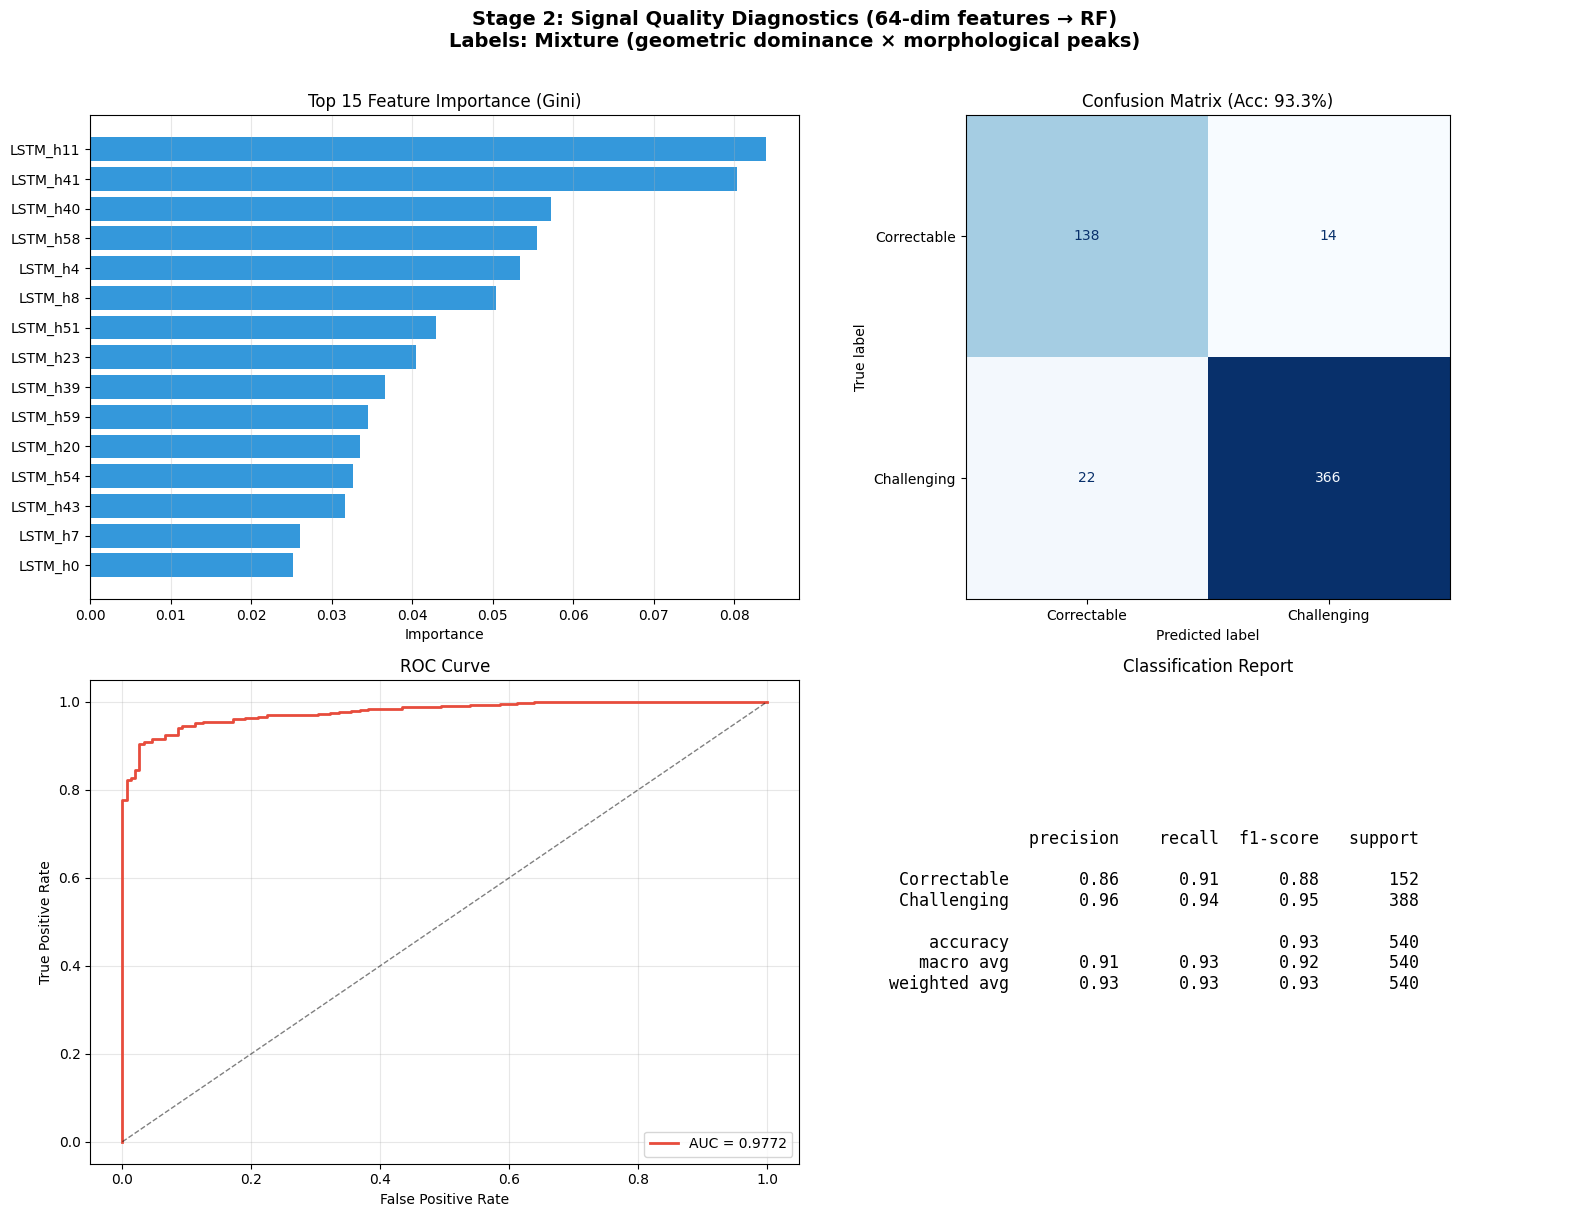


Top 15 Feature Importance (ranked):
  LSTM_h11                  0.0839
  LSTM_h41                  0.0803
  LSTM_h40                  0.0572
  LSTM_h58                  0.0556
  LSTM_h4                   0.0534
  LSTM_h8                   0.0504
  LSTM_h51                  0.0429
  LSTM_h23                  0.0405
  LSTM_h39                  0.0367
  LSTM_h59                  0.0345
  LSTM_h20                  0.0335
  LSTM_h54                  0.0326
  LSTM_h43                  0.0317
  LSTM_h7                   0.0261
  LSTM_h0                   0.0252


In [9]:
# ==========================================
# DIAGNOSTICS (using selected model from ablation)
# ==========================================
y_pred = rf_model.predict(X_test_final)

proba = rf_model.predict_proba(X_test_final)
if proba.shape[1] > 1:
    y_prob = proba[:, 1]
else:
    y_prob = proba[:, 0]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# 1. Feature Importance (top 15 dims)
ax = axs[0, 0]
importances = rf_model.feature_importances_
top_k = min(15, len(importances))
sorted_idx = np.argsort(importances)[-top_k:]
ax.barh(np.array(FEATURE_NAMES)[sorted_idx], importances[sorted_idx], color='#3498db')
if 'strongest_peak_power' in FEATURE_NAMES:
    spp_idx = FEATURE_NAMES.index('strongest_peak_power')
    if spp_idx in sorted_idx:
        rank_pos = np.where(sorted_idx == spp_idx)[0][0]
        bars = ax.patches
        if rank_pos < len(bars):
            bars[rank_pos].set_color('#e67e22')
    subtitle = "\n(orange = strongest_peak_power)" if spp_idx in sorted_idx else ""
else:
    subtitle = ""
ax.set_title(f"Top {top_k} Feature Importance (Gini){subtitle}")
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3, axis='x')

# 2. Confusion Matrix
ax = axs[0, 1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Correctable', 'Challenging'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
acc = (y_test == y_pred).mean()
ax.set_title(f"Confusion Matrix (Acc: {100*acc:.1f}%)")

# 3. ROC Curve
ax = axs[1, 0]
if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_title("ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')
else:
    ax.text(0.5, 0.5, 'Single class in test set', ha='center', va='center', fontsize=12)
    ax.set_title("ROC Curve (N/A)")
ax.grid(True, alpha=0.3)

# 4. Classification Report
ax = axs[1, 1]
report = classification_report(y_test, y_pred,
                               target_names=['Correctable', 'Challenging'])
ax.text(0.05, 0.5, report, fontsize=12, fontfamily='monospace',
        verticalalignment='center', transform=ax.transAxes)
ax.set_title("Classification Report")
ax.axis('off')

plt.suptitle(f"Stage 2: Signal Quality Diagnostics ({FEATURE_DIM}-dim features → RF)\n"
             f"Labels: Mixture (geometric dominance × morphological peaks)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nTop 15 Feature Importance (ranked):")
for feat, imp in sorted(zip(FEATURE_NAMES, importances), key=lambda x: -x[1])[:15]:
    print(f"  {feat:<25} {imp:.4f}")

if 'strongest_peak_power' in FEATURE_NAMES:
    spp_imp = importances[FEATURE_NAMES.index('strongest_peak_power')]
    spp_rank = int(np.sum(importances > spp_imp)) + 1
    print(f"\n  strongest_peak_power rank: #{spp_rank}/{len(FEATURE_NAMES)} (importance: {spp_imp:.4f})")

### 6b. Unseen Dataset Evaluation

Test both models on `unseen_dataset.csv` (1200 NLOS samples from 8.91m and 12.79m scenarios).

Loading: ../dataset/channels/unseen_dataset.csv
  Total samples: 2400, NLOS samples: 1200

  Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
    ──────────────────────────────────────────────────
    Correctable (clean bounce):     406 (33.8%)
    Challenging (multipath/noisy):   794 (66.2%)
    ──────────────────────────────────────────────────
    Bounce dominance stats — mean: 0.851, median: 1.000
    Peak count stats — mean: 3.91, max: 10
    Strongest peak power stats — mean: 18.6895, min: 5.9535, max: 49.7966

Unseen NLOS samples: 1200
  Correctable: 406, Challenging: 794
  Unseen embeddings shape: (1200, 64)


c:\Users\preca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\preca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\preca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave


UNSEEN DATASET: LSTM-only (64-dim) vs LSTM + strongest_peak_power (65-dim)
Dataset: unseen_dataset.csv (1200 NLOS samples)

Metric                    LSTM-only (64d)  LSTM+SPP (65d)          Δ
──────────────────────────────────────────────────────────────────────
Overall Accuracy                   76.42%          66.17%    -10.25%
ROC AUC                            0.8795          0.8794    -0.0001

Correctable precision               0.873           0.000     -0.873
Correctable recall                  0.355           0.000     -0.355
Correctable f1-score                0.504           0.000     -0.504

Challenging precision               0.747           0.662     -0.085
Challenging recall                  0.974           1.000     +0.026
Challenging f1-score                0.845           0.796     -0.049



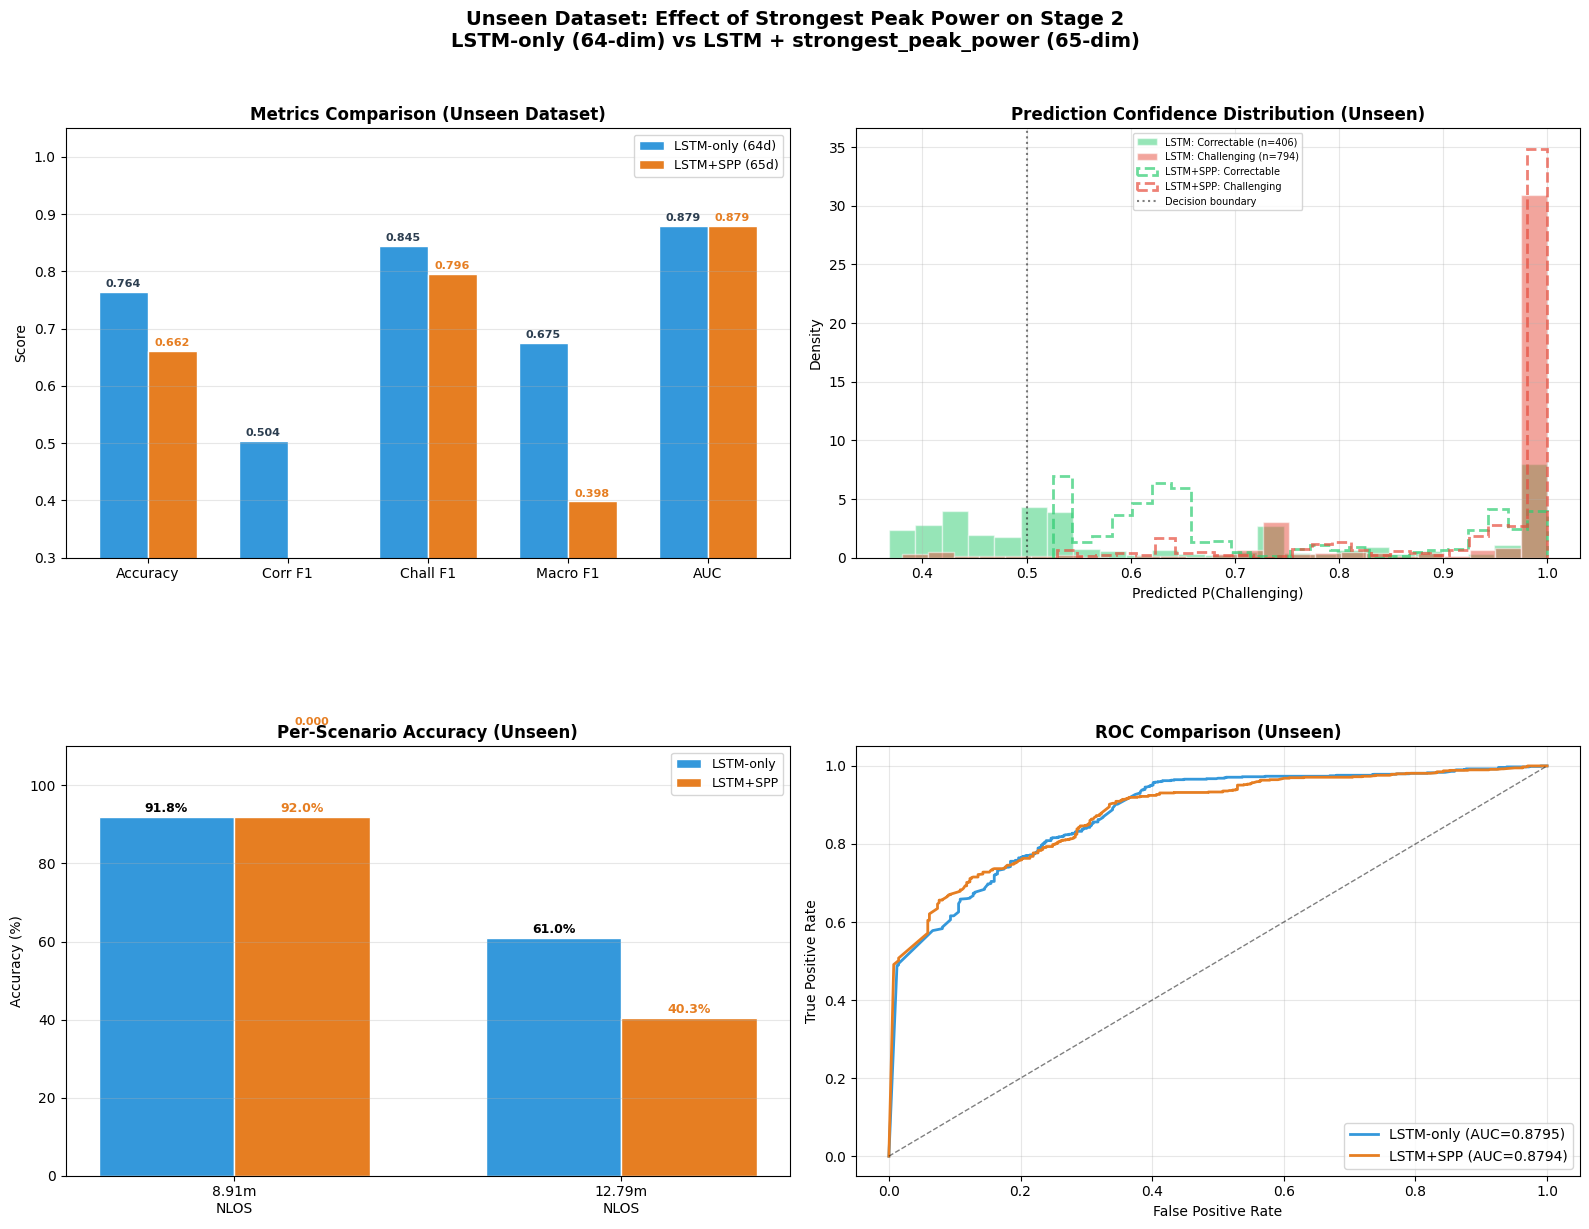


COMBINED SUMMARY
Dataset                LSTM-only Acc    LSTM+SPP Acc          Δ
─────────────────────────────────────────────────────────────────
Train split (30%)             93.33%          93.89%     +0.56%
Unseen dataset                76.42%          66.17%    -10.25%


In [10]:
# ==========================================
# UNSEEN DATASET EVALUATION — LSTM-only vs LSTM+SPP
# ==========================================
unseen_filepath = "../dataset/channels/unseen_dataset.csv"

# Load and process unseen NLOS data
(unseen_raw_sigs, unseen_leading_edges, unseen_nlos_df,
 unseen_labels, unseen_num_peaks, unseen_bounce_dom,
 unseen_spp) = load_nlos_features(unseen_filepath)

print(f"\nUnseen NLOS samples: {len(unseen_labels)}")
print(f"  Correctable: {int(np.sum(unseen_labels==0))}, Challenging: {int(np.sum(unseen_labels==1))}")

# Extract LSTM embeddings for unseen data
unseen_cir_sequences = []
for i in range(len(unseen_raw_sigs)):
    crop = preprocess_cir_for_lstm(unseen_raw_sigs[i], unseen_leading_edges[i])
    unseen_cir_sequences.append(crop)

unseen_cir_tensor = torch.tensor(
    np.array(unseen_cir_sequences).reshape(-1, STAGE1_CONFIG['total_len'], 1),
    dtype=torch.float32
).to(device)

unseen_embeddings_list = []
with torch.no_grad():
    for i in range(0, len(unseen_cir_tensor), 256):
        batch_cir = unseen_cir_tensor[i:i+256]
        emb = lstm_encoder.embed(batch_cir)
        unseen_embeddings_list.append(emb.cpu().numpy())

unseen_embeddings = np.vstack(unseen_embeddings_list)
print(f"  Unseen embeddings shape: {unseen_embeddings.shape}")

# ── Predict with both models ──
X_unseen_lstm = unseen_embeddings                                       # (N, 64)
X_unseen_spp = np.column_stack([unseen_embeddings, unseen_spp])         # (N, 65)
y_unseen = unseen_labels

# Version A: LSTM-only
y_pred_unseen_a = rf_lstm_only.predict(X_unseen_lstm)
acc_unseen_a = (y_unseen == y_pred_unseen_a).mean()
report_unseen_a = classification_report(y_unseen, y_pred_unseen_a,
                                         target_names=['Correctable', 'Challenging'], output_dict=True)
proba_unseen_a = rf_lstm_only.predict_proba(X_unseen_lstm)
y_prob_unseen_a = proba_unseen_a[:, 1] if proba_unseen_a.shape[1] > 1 else proba_unseen_a[:, 0]
fpr_ua, tpr_ua, _ = roc_curve(y_unseen, y_prob_unseen_a)
auc_ua = auc(fpr_ua, tpr_ua)

# Version B: LSTM + SPP
y_pred_unseen_b = rf_with_spp.predict(X_unseen_spp)
acc_unseen_b = (y_unseen == y_pred_unseen_b).mean()
report_unseen_b = classification_report(y_unseen, y_pred_unseen_b,
                                         target_names=['Correctable', 'Challenging'], output_dict=True)
proba_unseen_b = rf_with_spp.predict_proba(X_unseen_spp)
y_prob_unseen_b = proba_unseen_b[:, 1] if proba_unseen_b.shape[1] > 1 else proba_unseen_b[:, 0]
fpr_ub, tpr_ub, _ = roc_curve(y_unseen, y_prob_unseen_b)
auc_ub = auc(fpr_ub, tpr_ub)

# ── Per-scenario accuracy (unseen) ──
unseen_scenarios = np.array([
    re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
    if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
    for sf in unseen_nlos_df['Source_File'].values
])
unseen_unique_scenarios = sorted(set(unseen_scenarios), key=lambda x: float(x.replace('m', '')))

# ── Print comparison ──
print("\n" + "=" * 70)
print("UNSEEN DATASET: LSTM-only (64-dim) vs LSTM + strongest_peak_power (65-dim)")
print("=" * 70)
print(f"Dataset: unseen_dataset.csv ({len(y_unseen)} NLOS samples)")
print()

metrics = ['precision', 'recall', 'f1-score']
print(f"{'Metric':<25} {'LSTM-only (64d)':>15} {'LSTM+SPP (65d)':>15} {'Δ':>10}")
print("─" * 70)
print(f"{'Overall Accuracy':<25} {100*acc_unseen_a:>14.2f}% {100*acc_unseen_b:>14.2f}% {100*(acc_unseen_b-acc_unseen_a):>+9.2f}%")
print(f"{'ROC AUC':<25} {auc_ua:>15.4f} {auc_ub:>15.4f} {auc_ub-auc_ua:>+10.4f}")
print()
for cls in ['Correctable', 'Challenging']:
    for m in metrics:
        va = report_unseen_a[cls][m]
        vb = report_unseen_b[cls][m]
        print(f"{cls + ' ' + m:<25} {va:>15.3f} {vb:>15.3f} {vb-va:>+10.3f}")
    print()

# ── VISUALIZATION ──
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.35)

# ─── Plot 1: Grouped bar chart — key metrics ───
ax = axs[0, 0]
metric_names = ['Accuracy', 'Corr F1', 'Chall F1', 'Macro F1', 'AUC']
vals_ua = [acc_unseen_a, report_unseen_a['Correctable']['f1-score'],
           report_unseen_a['Challenging']['f1-score'],
           report_unseen_a['macro avg']['f1-score'], auc_ua]
vals_ub = [acc_unseen_b, report_unseen_b['Correctable']['f1-score'],
           report_unseen_b['Challenging']['f1-score'],
           report_unseen_b['macro avg']['f1-score'], auc_ub]

x_pos = np.arange(len(metric_names))
w = 0.35
bars_a = ax.bar(x_pos - w/2, vals_ua, w, color='#3498db', label='LSTM-only (64d)', edgecolor='white')
bars_b = ax.bar(x_pos + w/2, vals_ub, w, color='#e67e22', label='LSTM+SPP (65d)', edgecolor='white')

for bar, val in zip(bars_a, vals_ua):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2c3e50')
for bar, val in zip(bars_b, vals_ub):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#e67e22')

ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0.3, 1.05)
ax.set_ylabel('Score')
ax.set_title('Metrics Comparison (Unseen Dataset)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ─── Plot 2: Prediction probability distributions (unseen) ───
ax = axs[0, 1]
corr_mask_u = y_unseen == 0
chall_mask_u = y_unseen == 1
ax.hist(y_prob_unseen_a[corr_mask_u], bins=25, alpha=0.5, color='#2ecc71', density=True,
        label=f'LSTM: Correctable (n={corr_mask_u.sum()})', edgecolor='white')
ax.hist(y_prob_unseen_a[chall_mask_u], bins=25, alpha=0.5, color='#e74c3c', density=True,
        label=f'LSTM: Challenging (n={chall_mask_u.sum()})', edgecolor='white')
ax.hist(y_prob_unseen_b[corr_mask_u], bins=25, alpha=0.7, color='#2ecc71', density=True,
        histtype='step', lw=2, linestyle='--', label='LSTM+SPP: Correctable')
ax.hist(y_prob_unseen_b[chall_mask_u], bins=25, alpha=0.7, color='#e74c3c', density=True,
        histtype='step', lw=2, linestyle='--', label='LSTM+SPP: Challenging')
ax.axvline(0.5, color='black', ls=':', lw=1.5, alpha=0.5, label='Decision boundary')
ax.set_xlabel('Predicted P(Challenging)')
ax.set_ylabel('Density')
ax.set_title('Prediction Confidence Distribution (Unseen)', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, loc='upper center')
ax.grid(True, alpha=0.3)

# ─── Plot 3: Per-scenario accuracy breakdown (unseen) ───
ax = axs[1, 0]
scenario_acc_ua = []
scenario_acc_ub = []
for sc in unseen_unique_scenarios:
    mask = unseen_scenarios == sc
    if mask.sum() > 0:
        scenario_acc_ua.append((y_unseen[mask] == y_pred_unseen_a[mask]).mean())
        scenario_acc_ub.append((y_unseen[mask] == y_pred_unseen_b[mask]).mean())
    else:
        scenario_acc_ua.append(0)
        scenario_acc_ub.append(0)

x_sc = np.arange(len(unseen_unique_scenarios))
bars_sa = ax.bar(x_sc - w/2, [100*v for v in scenario_acc_ua], w,
                 color='#3498db', label='LSTM-only', edgecolor='white')
bars_sb = ax.bar(x_sc + w/2, [100*v for v in scenario_acc_ub], w,
                 color='#e67e22', label='LSTM+SPP', edgecolor='white')

for bar, val in zip(bars_sa, scenario_acc_ua):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{100*val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars_sb, scenario_acc_ub):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{100*val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#e67e22')

ax.set_xticks(x_sc)
ax.set_xticklabels([f'{s}\nNLOS' for s in unseen_unique_scenarios], fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Scenario Accuracy (Unseen)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 110)

# ─── Plot 4: ROC overlay ───
ax = axs[1, 1]
ax.plot(fpr_ua, tpr_ua, color='#3498db', lw=2, label=f'LSTM-only (AUC={auc_ua:.4f})')
ax.plot(fpr_ub, tpr_ub, color='#e67e22', lw=2, label=f'LSTM+SPP (AUC={auc_ub:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Comparison (Unseen)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Unseen Dataset: Effect of Strongest Peak Power on Stage 2\n'
             'LSTM-only (64-dim) vs LSTM + strongest_peak_power (65-dim)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Combined summary ──
print("\n" + "=" * 70)
print("COMBINED SUMMARY")
print("=" * 70)
print(f"{'Dataset':<20} {'LSTM-only Acc':>15} {'LSTM+SPP Acc':>15} {'Δ':>10}")
print("─" * 65)
print(f"{'Train split (30%)' :<20} {100*acc_a:>14.2f}% {100*acc_b:>14.2f}% {100*(acc_b-acc_a):>+9.2f}%")
print(f"{'Unseen dataset':<20} {100*acc_unseen_a:>14.2f}% {100*acc_unseen_b:>14.2f}% {100*(acc_unseen_b-acc_unseen_a):>+9.2f}%")

## 7. Save Artifacts

In [11]:
# ==========================================
# SAVE ARTIFACTS
# ==========================================
joblib.dump(rf_model, "stage2_bounce_rf.joblib")
print("Saved: stage2_bounce_rf.joblib")

joblib.dump({
    "config": CONFIG,
    "embedding_dim": EMBEDDING_DIM,
    "embedding_names": EMBEDDING_NAMES,
    "feature_dim": FEATURE_DIM,
    "feature_names": FEATURE_NAMES,
    "extra_features": [f for f in FEATURE_NAMES if f not in EMBEDDING_NAMES],
    "stage1_config": STAGE1_CONFIG,
    "encoder_class": "LSTM_Classifier",
    "fp_conditioning": False,
    "label_strategy": "mixture_geometric_morphological",
    "dominance_type": "amplitude_ratio",
    "dominance_threshold": CONFIG["dominance_threshold"],
    "bounce_search_window": CONFIG["bounce_search_window"],
    "dominant_path_max_peaks": CONFIG["dominant_path_max_peaks"],
    "note": f"Mixture labels: Correctable if bounce amplitude ratio >= {CONFIG['dominance_threshold']:.0%} "
            f"AND num_peaks <= {CONFIG['dominant_path_max_peaks']}. "
            f"Dominance = bounce_peak_amp / strongest_peak_amp (not energy ratio). "
            f"Model input is {FEATURE_DIM}-dim ({EMBEDDING_DIM} LSTM embeddings"
            f"{' + ' + str(FEATURE_DIM - EMBEDDING_DIM) + ' extra features' if FEATURE_DIM > EMBEDDING_DIM else ''}). "
            f"RF predicts signal quality from embeddings alone.",
}, "stage2_config.joblib")
print("Saved: stage2_config.joblib")

print(f"\nDependency: stage1_lstm_best.pt (frozen LSTM_Classifier encoder)")
print(f"Feature dim: {FEATURE_DIM} ({'LSTM embeddings only' if FEATURE_DIM == 64 else 'LSTM + extra features'})")
print(f"Artifacts ready for Stage 3 pipeline.")

Saved: stage2_bounce_rf.joblib
Saved: stage2_config.joblib

Dependency: stage1_lstm_best.pt (frozen LSTM_Classifier encoder)
Feature dim: 64 (LSTM embeddings only)
Artifacts ready for Stage 3 pipeline.


In [12]:
print("=" * 60)
print("Stage 2 — Summary")
print("=" * 60)
print(f"Model artifact: stage2_bounce_rf.joblib")
print(f"Config artifact: stage2_config.joblib")
print(f"Encoder dependency: stage1_lstm_best.pt (frozen LSTM_Classifier)")
print()
print(f"Architecture: Frozen LSTM_Classifier encoder → {FEATURE_DIM}-dim features → RF classifier")
print(f"  LSTM embeddings: {EMBEDDING_DIM}-dim (avg-pooled hidden states)")
if FEATURE_DIM > EMBEDDING_DIM:
    print(f"  Extra features: {FEATURE_NAMES[EMBEDDING_DIM:]}")
print()
print(f"Ablation: LSTM-only (64d) vs LSTM+SPP (65d)")
print(f"  Train split:  LSTM-only={100*acc_a:.2f}%, LSTM+SPP={100*acc_b:.2f}% (Δ={100*(acc_b-acc_a):+.2f}%)")
print(f"  Unseen data:  LSTM-only={100*acc_unseen_a:.2f}%, LSTM+SPP={100*acc_unseen_b:.2f}% (Δ={100*(acc_unseen_b-acc_unseen_a):+.2f}%)")
print(f"  Selected: {'LSTM-only' if FEATURE_DIM == 64 else 'LSTM+SPP'} ({FEATURE_DIM}-dim)")
print()
print(f"Labels: MIXTURE (geometric + morphological)")
print(f"  Criterion 1: bounce dominance (amplitude ratio) >= {CONFIG['dominance_threshold']:.0%}")
print(f"  Criterion 2: num_peaks <= {CONFIG['dominant_path_max_peaks']}")
print(f"  Correctable (0): BOTH conditions met")
print(f"  Challenging (1): either condition violated")
print(f"Test Accuracy: {100*test_acc:.2f}%")
print()
print("Pipeline: Stage 1 (LSTM) → Stage 2 (LSTM embeddings → RF → signal quality) → Stage 3 (ranging error)")

Stage 2 — Summary
Model artifact: stage2_bounce_rf.joblib
Config artifact: stage2_config.joblib
Encoder dependency: stage1_lstm_best.pt (frozen LSTM_Classifier)

Architecture: Frozen LSTM_Classifier encoder → 64-dim features → RF classifier
  LSTM embeddings: 64-dim (avg-pooled hidden states)

Ablation: LSTM-only (64d) vs LSTM+SPP (65d)
  Train split:  LSTM-only=93.33%, LSTM+SPP=93.89% (Δ=+0.56%)
  Unseen data:  LSTM-only=76.42%, LSTM+SPP=66.17% (Δ=-10.25%)
  Selected: LSTM-only (64-dim)

Labels: MIXTURE (geometric + morphological)
  Criterion 1: bounce dominance (amplitude ratio) >= 50%
  Criterion 2: num_peaks <= 2
  Correctable (0): BOTH conditions met
  Challenging (1): either condition violated
Test Accuracy: 93.33%

Pipeline: Stage 1 (LSTM) → Stage 2 (LSTM embeddings → RF → signal quality) → Stage 3 (ranging error)
